In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rupakroy/online-payments-fraud-detection-dataset/PS_20174392719_1491204439457_log.csv


In [2]:
df=pd.read_csv('/kaggle/input/datasets/rupakroy/online-payments-fraud-detection-dataset/PS_20174392719_1491204439457_log.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df[
    (df['newbalanceOrig'] != 0) &
    (df['oldbalanceDest'] != 0) &
    (df['newbalanceDest'] != 0) &
    (df['isFraud'] == 1)
]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
60853,9,TRANSFER,994453.20,C1121789613,1437370.87,442917.67,C254839817,194812.76,665743.67,1,0
377151,17,CASH_OUT,42062.82,C897869440,340830.43,298767.61,C616721459,398931.35,678419.64,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.shape

(6362620, 11)

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [8]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df[(df['type']=='TRANSFER') | (df['type']=='PAYEMENT')]['isFraud'].value_counts()

isFraud
0    528812
1      4097
Name: count, dtype: int64

# removing useless features

In [11]:
df = df.drop('isFlaggedFraud',axis=1)

In [12]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [13]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

**We removed CASH_OUT, CASH_IN, and DEBIT transactions to reduce noise and focus on transaction types more relevant to fraud analysis.**

In [14]:
df = df[df['type'].isin(['TRANSFER', 'PAYMENT'])]

In [15]:
df.shape

(2684404, 8)

In [16]:
df[df.duplicated()]

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
11104,7,PAYMENT,1849.50,0.0,0.0,0.0,0.0,0
33556,8,PAYMENT,7759.31,0.0,0.0,0.0,0.0,0
59969,9,PAYMENT,2388.93,0.0,0.0,0.0,0.0,0
60763,9,PAYMENT,10042.85,0.0,0.0,0.0,0.0,0
63096,9,PAYMENT,2783.83,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...
5962682,406,PAYMENT,3610.59,0.0,0.0,0.0,0.0,0
5965015,406,PAYMENT,6724.61,0.0,0.0,0.0,0.0,0
6099127,522,PAYMENT,17961.80,0.0,0.0,0.0,0.0,0
6152053,546,PAYMENT,16108.65,0.0,0.0,0.0,0.0,0


In [17]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.0,0.0,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.0,0
2,1,TRANSFER,181.00,181.00,0.00,0.0,0.0,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.0,0.0,0
5,1,PAYMENT,7817.71,53860.00,46042.29,0.0,0.0,0
...,...,...,...,...,...,...,...,...
6362610,742,TRANSFER,63416.99,63416.99,0.00,0.0,0.0,1
6362612,743,TRANSFER,1258818.82,1258818.82,0.00,0.0,0.0,1
6362614,743,TRANSFER,339682.13,339682.13,0.00,0.0,0.0,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.0,0.0,1


# Feature Engineering 

Transaction Time Features
1. hour → Stores the hour when the transaction happened.
2. is_night → Marks transactions done between 12 AM and 6 AM, since fraud is more common at night.

In [18]:
df['hour'] = df['step']% 24
df['is_night'] = (df['hour'] < 6).astype(int)

In [19]:
df.sample(5)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night
5430952,378,PAYMENT,3375.90,167.0,0.00,0.00,0.00,0,18,0
2584131,207,TRANSFER,113055.71,0.0,0.00,181035.31,294091.02,0,15,0
4772600,335,PAYMENT,4610.13,0.0,0.00,0.00,0.00,0,23,0
5531700,381,PAYMENT,5629.68,0.0,0.00,0.00,0.00,0,21,0
541814,21,PAYMENT,8518.67,147701.0,139182.33,0.00,0.00,0,21,0


In [20]:
df[df['is_night']==1]['isFraud'].value_counts()

isFraud
0    70701
1      997
Name: count, dtype: int64

## 1.2 Transaction Amount Features

- Compares transaction amounts with sender's balance
- `amount_ratio` measures how significant the transaction amount is compared to the sender's balance
- High values (close to 1) may indicate risky or suspicious transactions

In [21]:
df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)  # Avoid division by zero

In [22]:
df.sample(5)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio
4722765,332,PAYMENT,57250.93,7903.0,0.0,0.00,0.00,0,20,0,7.243286
3627449,274,PAYMENT,18164.06,0.0,0.0,0.00,0.00,0,10,0,18164.060000
5493135,380,PAYMENT,16627.09,0.0,0.0,0.00,0.00,0,20,0,16627.090000
1573185,155,TRANSFER,137350.13,0.0,0.0,5223872.36,5361222.49,0,11,0,137350.130000
3995840,298,PAYMENT,57304.07,302.0,0.0,0.00,0.00,0,10,0,189.122343


## 1.3 Balance Difference Features

- Checks unusual balance changes after transactions
- `sender_balance_change` shows the difference between sender’s old and new balance
- `receiver_balance_change` shows the difference between receiver’s old and new balance
- Fraudulent transactions may not update balances correctly, which can indicate suspicious activity

In [23]:
df['sender_balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['receiver_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']

In [24]:
df[df['isFraud']==1]

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change
2,1,TRANSFER,181.00,181.00,0.0,0.0,0.0,1,1,1,0.994505,181.00,0.0
251,1,TRANSFER,2806.00,2806.00,0.0,0.0,0.0,1,1,1,0.999644,2806.00,0.0
680,1,TRANSFER,20128.00,20128.00,0.0,0.0,0.0,1,1,1,0.999950,20128.00,0.0
969,1,TRANSFER,1277212.77,1277212.77,0.0,0.0,0.0,1,1,1,0.999999,1277212.77,0.0
1115,1,TRANSFER,35063.63,35063.63,0.0,0.0,0.0,1,1,1,0.999971,35063.63,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362610,742,TRANSFER,63416.99,63416.99,0.0,0.0,0.0,1,22,0,0.999984,63416.99,0.0
6362612,743,TRANSFER,1258818.82,1258818.82,0.0,0.0,0.0,1,23,0,0.999999,1258818.82,0.0
6362614,743,TRANSFER,339682.13,339682.13,0.0,0.0,0.0,1,23,0,0.999997,339682.13,0.0
6362616,743,TRANSFER,6311409.28,6311409.28,0.0,0.0,0.0,1,23,0,1.000000,6311409.28,0.0


# 1.4 Unexpected Zero Balance 
**Fraudsters may use new accounts with zero balance to receive money.**

In [25]:
df['sender_balance_zero'] = (df['oldbalanceOrg'] == 0).astype(int)
df['receiver_balance_zero'] = (df['oldbalanceDest'] == 0).astype(int)

In [26]:
df.sample(4)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,sender_balance_zero,receiver_balance_zero
6171862,563,PAYMENT,7866.77,31072.0,23205.23,0.00,0.00,0,11,0,0.253171,7866.77,0.00,0,1
3918920,284,TRANSFER,87631.61,25097.0,0.00,146840.63,234472.24,0,20,0,3.491577,25097.00,87631.61,0,0
770688,39,TRANSFER,251935.20,706.0,0.00,0.00,251935.20,0,15,0,356.343989,706.00,251935.20,0,1
994865,45,TRANSFER,136066.22,32209.0,0.00,410622.90,546689.12,0,21,0,4.224347,32209.00,136066.22,0,0


In [27]:
df[df['isFraud']==1]

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,sender_balance_zero,receiver_balance_zero
2,1,TRANSFER,181.00,181.00,0.0,0.0,0.0,1,1,1,0.994505,181.00,0.0,0,1
251,1,TRANSFER,2806.00,2806.00,0.0,0.0,0.0,1,1,1,0.999644,2806.00,0.0,0,1
680,1,TRANSFER,20128.00,20128.00,0.0,0.0,0.0,1,1,1,0.999950,20128.00,0.0,0,1
969,1,TRANSFER,1277212.77,1277212.77,0.0,0.0,0.0,1,1,1,0.999999,1277212.77,0.0,0,1
1115,1,TRANSFER,35063.63,35063.63,0.0,0.0,0.0,1,1,1,0.999971,35063.63,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362610,742,TRANSFER,63416.99,63416.99,0.0,0.0,0.0,1,22,0,0.999984,63416.99,0.0,0,1
6362612,743,TRANSFER,1258818.82,1258818.82,0.0,0.0,0.0,1,23,0,0.999999,1258818.82,0.0,0,1
6362614,743,TRANSFER,339682.13,339682.13,0.0,0.0,0.0,1,23,0,0.999997,339682.13,0.0,0,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.0,0.0,0.0,1,23,0,1.000000,6311409.28,0.0,0,1


# Encoding Categorical Features

In [28]:
dummies=pd.get_dummies(df['type']).astype(int)
dummies.tail()

,PAYMENT,TRANSFER
6362610,0,1
6362612,0,1
6362614,0,1
6362616,0,1
6362618,0,1


In [29]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [30]:
df['type_TRANSFER'] = df['type_TRANSFER'].astype(int)
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,sender_balance_zero,receiver_balance_zero,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,1,1,0.057834,9839.64,0.0,0,1,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,1,1,0.087731,1864.28,0.0,0,1,0
2,1,181.00,181.0,0.00,0.0,0.0,1,1,1,0.994505,181.00,0.0,0,1,1
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,1,1,0.280788,11668.14,0.0,0,1,0
5,1,7817.71,53860.0,46042.29,0.0,0.0,0,1,1,0.145146,7817.71,0.0,0,1,0


In [31]:
df.sample(10)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,sender_balance_zero,receiver_balance_zero,type_TRANSFER
5562726,385,3041.32,258429.0,255387.68,0.00,0.00,0,1,1,1.176845e-02,3041.32,0.00,0,1,0
5446326,379,11144.86,23978.0,12833.14,0.00,0.00,0,19,0,4.647758e-01,11144.86,0.00,0,1,0
3870363,283,26351.58,0.0,0.00,0.00,0.00,0,19,0,2.635158e+04,0.00,0.00,1,1,0
1796186,162,14921.84,72273.0,57351.16,0.00,0.00,0,18,0,2.064621e-01,14921.84,0.00,0,1,0
462074,19,3436.63,16840.0,13403.37,0.00,0.00,0,19,0,2.040633e-01,3436.63,0.00,0,1,0
4137744,303,33537.70,215462.0,181924.30,0.00,0.00,0,15,0,1.556541e-01,33537.70,0.00,0,1,0
5599377,394,46760.03,52312.0,5551.97,0.00,0.00,0,10,0,8.938511e-01,46760.03,0.00,0,1,0
3835357,282,1995.29,22753.0,20757.71,0.00,0.00,0,18,0,8.768964e-02,1995.29,0.00,0,1,0
4159931,304,8876280.43,0.0,0.00,30374835.34,39251115.77,0,16,0,8.876280e+06,0.00,8876280.43,1,0,1
1587159,155,1184047.84,222526.0,0.00,2526498.26,3710546.10,0,11,0,5.320918e+00,222526.00,1184047.84,0,0,1


<Axes: >

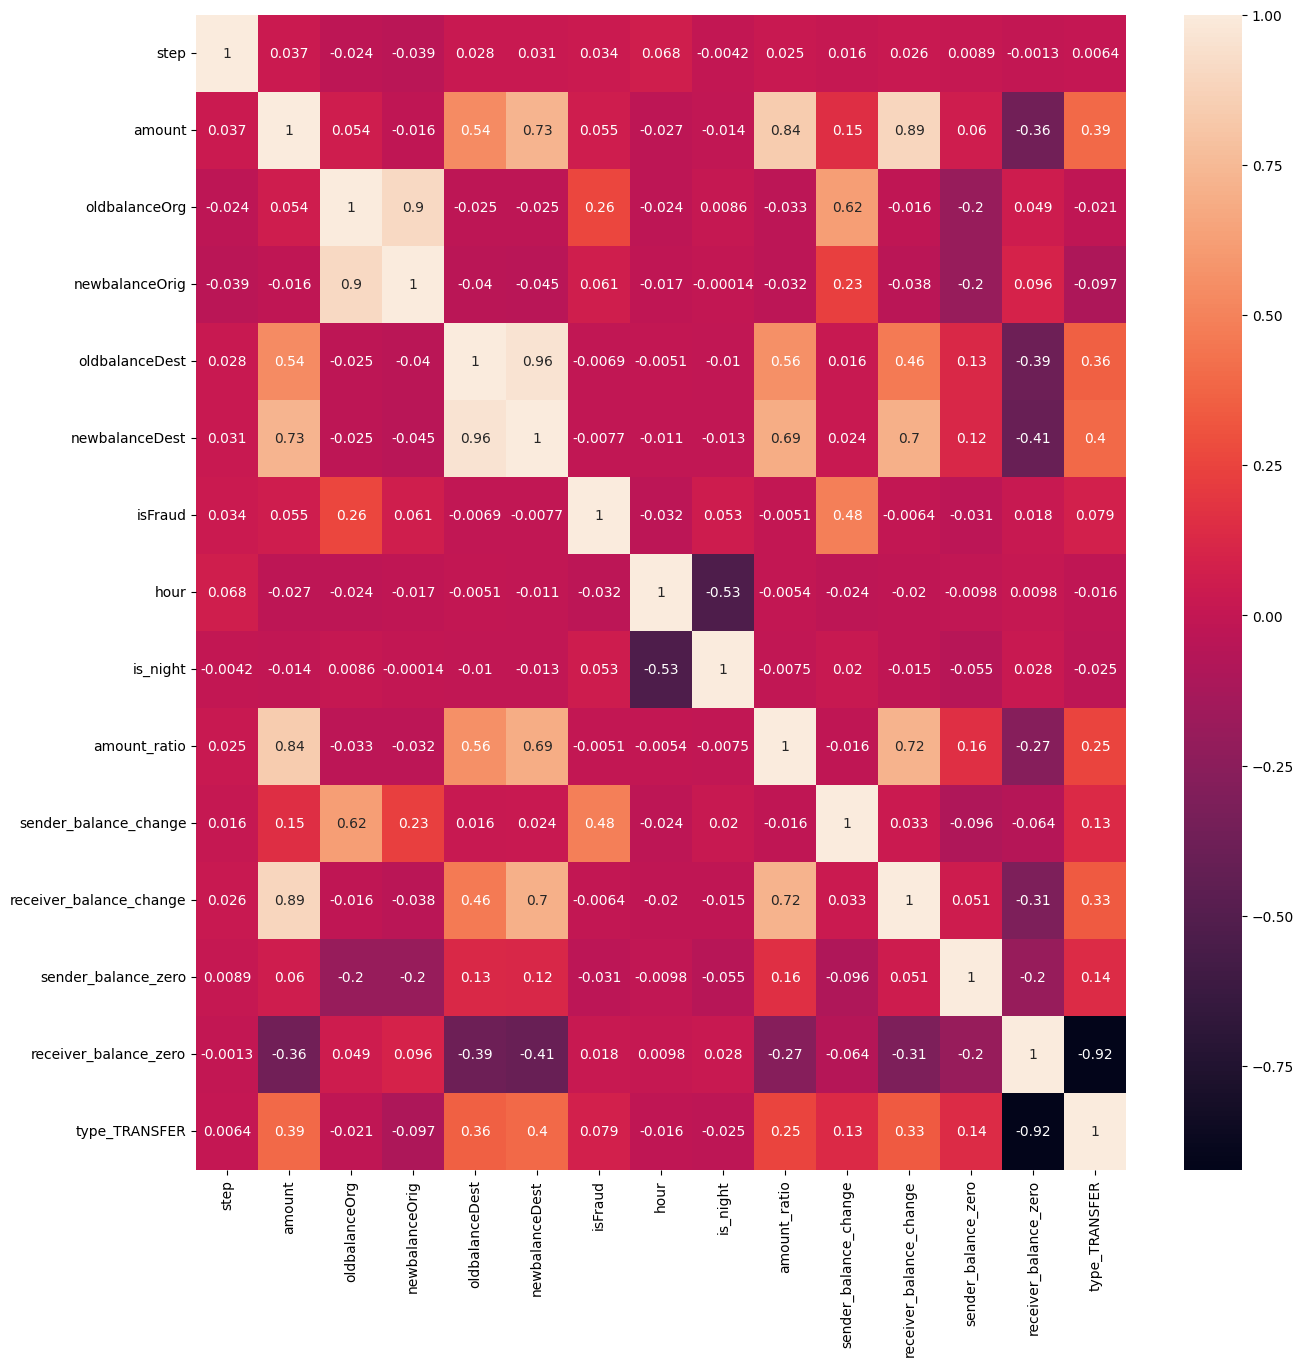

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
corr=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr ,annot=True)

In [33]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,sender_balance_zero,receiver_balance_zero,type_TRANSFER
count,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06,2.684404e+06
mean,2.448306e+02,1.912474e+05,6.548221e+04,5.160422e+04,5.097222e+05,7.056541e+05,1.526223e-03,1.535208e+01,2.670909e-02,1.020612e+05,1.387800e+04,1.959319e+05,3.937664e-01,8.257431e-01,1.985204e-01
std,1.431616e+02,9.108498e+05,2.649473e+05,2.125782e+05,2.878561e+06,3.583985e+06,3.903709e-02,4.676800e+00,1.612319e-01,7.723748e+05,1.169518e+05,1.184107e+06,4.885842e-01,3.793303e-01,3.988861e-01
min,1.000000e+00,2.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.462010e-07,0.000000e+00,-6.755514e+06,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,5.501128e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.200000e+01,0.000000e+00,2.020453e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
50%,2.490000e+02,1.270320e+04,7.030000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.853779e+00,1.650680e+03,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,3.450000e+02,3.276679e+04,5.228100e+04,3.089579e+04,0.000000e+00,0.000000e+00,0.000000e+00,1.900000e+01,0.000000e+00,9.618353e+03,1.058907e+04,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.553805e+08,3.560159e+08,1.000000e+00,2.300000e+01,1.000000e+00,9.244552e+07,1.000000e+07,1.056878e+08,1.000000e+00,1.000000e+00,1.000000e+00


In [34]:
X = df.drop('isFraud',axis=1)
y = df['isFraud']

In [35]:
X

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,sender_balance_zero,receiver_balance_zero,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.0,0.0,1,1,0.057834,9839.64,0.0,0,1,0
1,1,1864.28,21249.00,19384.72,0.0,0.0,1,1,0.087731,1864.28,0.0,0,1,0
2,1,181.00,181.00,0.00,0.0,0.0,1,1,0.994505,181.00,0.0,0,1,1
4,1,11668.14,41554.00,29885.86,0.0,0.0,1,1,0.280788,11668.14,0.0,0,1,0
5,1,7817.71,53860.00,46042.29,0.0,0.0,1,1,0.145146,7817.71,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362610,742,63416.99,63416.99,0.00,0.0,0.0,22,0,0.999984,63416.99,0.0,0,1,1
6362612,743,1258818.82,1258818.82,0.00,0.0,0.0,23,0,0.999999,1258818.82,0.0,0,1,1
6362614,743,339682.13,339682.13,0.00,0.0,0.0,23,0,0.999997,339682.13,0.0,0,1,1
6362616,743,6311409.28,6311409.28,0.00,0.0,0.0,23,0,1.000000,6311409.28,0.0,0,1,1


In [36]:
y

0          0
1          0
2          1
4          0
5          0
          ..
6362610    1
6362612    1
6362614    1
6362616    1
6362618    1
Name: isFraud, Length: 2684404, dtype: int64

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42,shuffle=True)

In [38]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2013303, 14), (671101, 14), (2013303,), (671101,))

In [39]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [40]:
X_train_scaled

array([[-0.11740631,  0.02550296, -0.23807271, ...,  1.24078014,
        -2.17655541,  2.00964526],
       [ 0.39949745, -0.19588309, -0.2166288 , ..., -0.80594456,
         0.45944155, -0.49760026],
       [-0.22916929, -0.20482755, -0.23807271, ...,  1.24078014,
         0.45944155, -0.49760026],
       ...,
       [ 1.04213456,  0.08556266, -0.15567094, ..., -0.80594456,
        -2.17655541,  2.00964526],
       [ 0.89544566, -0.18880476, -0.19843462, ..., -0.80594456,
         0.45944155, -0.49760026],
       [ 0.88846047,  0.84042163, -0.19862663, ..., -0.80594456,
        -2.17655541,  2.00964526]])

# Train using Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter = 1000)

In [42]:
lr.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [43]:
y_pred1 = lr.predict(X_test_scaled)
y_pred1

array([0, 0, 0, ..., 0, 0, 0])

In [44]:
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report
acc_score = accuracy_score(y_test,y_pred1)
print(f"accuracy score :{acc_score} ")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred1))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred1))

accuracy score :0.9996334381859064 

Confusion matrix :
[[670048      6]
 [   240    807]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670054
           1       0.99      0.77      0.87      1047

    accuracy                           1.00    671101
   macro avg       1.00      0.89      0.93    671101
weighted avg       1.00      1.00      1.00    671101



# train using Decision Tree

In [45]:
from sklearn.tree import DecisionTreeClassifier

In [46]:
dt = DecisionTreeClassifier(max_depth=5,class_weight={0:1,1:10})

In [47]:
dt.fit(X_train,y_train)

DecisionTreeClassifier(class_weight={0: 1, 1: 10}, max_depth=5)

[Text(0.5260416666666666, 0.9166666666666666, 'x[9] <= 434002.766\ngini = 0.029\nsamples = 2013303\nvalue = [2010253, 30500]'),
 Text(0.2604166666666667, 0.75, 'x[9] <= 71216.309\ngini = 0.015\nsamples = 2007775\nvalue = [2006286, 14890]'),
 Text(0.39322916666666663, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'x[0] <= 718.5\ngini = 0.005\nsamples = 1958702\nvalue = [1958205, 4970]'),
 Text(0.08333333333333333, 0.4166666666666667, 'x[13] <= 0.5\ngini = 0.005\nsamples = 1958688\nvalue = [1958205, 4830]'),
 Text(0.041666666666666664, 0.25, 'gini = 0.0\nsamples = 1612276\nvalue = [1612276, 0]'),
 Text(0.125, 0.25, 'x[5] <= 57.855\ngini = 0.027\nsamples = 346412\nvalue = [345929, 4830]'),
 Text(0.08333333333333333, 0.08333333333333333, 'gini = 0.225\nsamples = 1178\nvalue = [704, 4740]'),
 Text(0.16666666666666666, 0.08333333333333333, 'gini = 0.001\nsamples = 345234\nvalue = [345225, 90]'),
 Text(0.16666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 14\nvalue

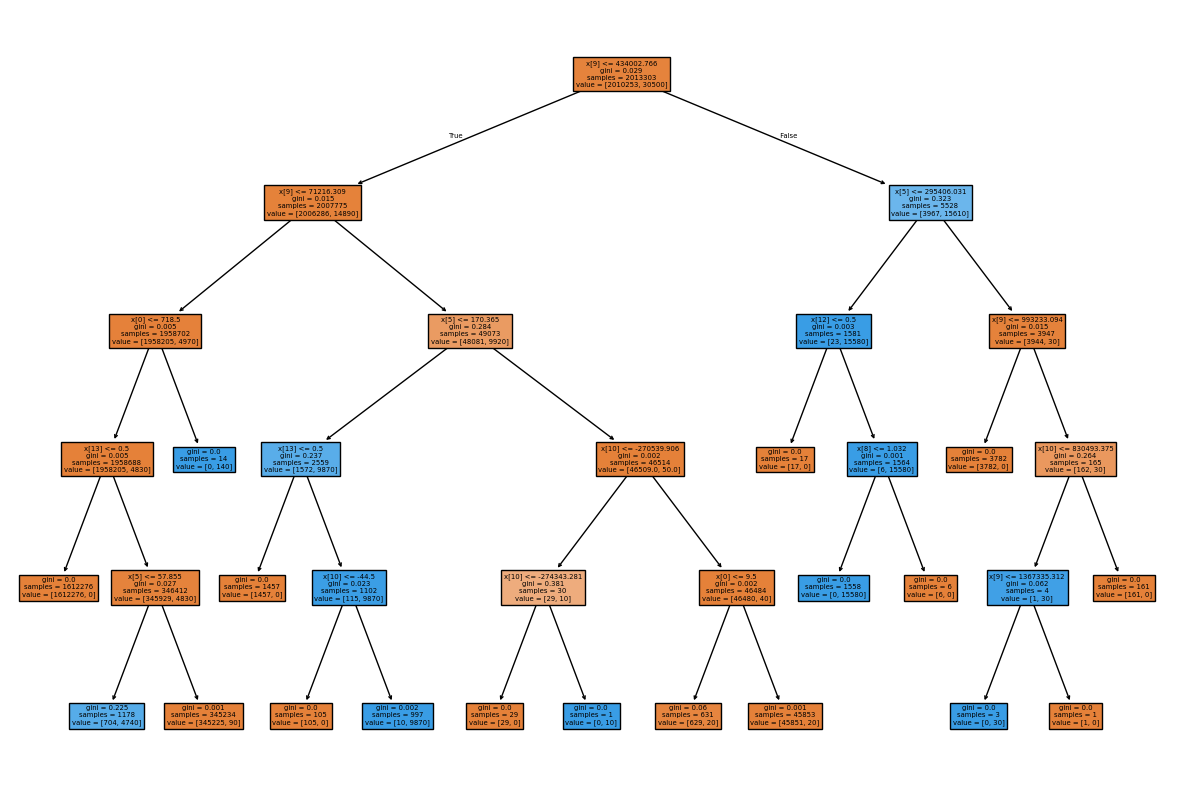

In [48]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dt,filled=True)

In [49]:
dt.get_depth()

5

In [50]:
y_pred2 = dt.predict(X_test)

In [51]:
y_pred2

array([0, 0, 0, ..., 0, 0, 0])

In [52]:
acc_score=accuracy_score(y_test,y_pred2)
print(f"accuracy score :{acc_score} ")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred2))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred2))

accuracy score :0.9996319480972312 

Confusion matrix :
[[669811    243]
 [     4   1043]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670054
           1       0.81      1.00      0.89      1047

    accuracy                           1.00    671101
   macro avg       0.91      1.00      0.95    671101
weighted avg       1.00      1.00      1.00    671101



# Training with Random forest

In [53]:
from sklearn.ensemble import RandomForestClassifier 

In [54]:
rf = RandomForestClassifier(n_estimators = 100,class_weight={0:1,1:10},random_state=42)

In [55]:
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight={0: 1, 1: 10}, random_state=42)

In [56]:
y_pred3 = rf.predict(X_test)
y_pred3

array([0, 0, 0, ..., 0, 0, 0])

In [58]:
acc_score=accuracy_score(y_test,y_pred3)*100
print(f"accuracy score :{acc_score} %")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred3))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred3))

accuracy score :99.99985099113248 %

Confusion matrix :
[[670054      0]
 [     1   1046]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670054
           1       1.00      1.00      1.00      1047

    accuracy                           1.00    671101
   macro avg       1.00      1.00      1.00    671101
weighted avg       1.00      1.00      1.00    671101



In [61]:
import joblib


joblib.dump(rf, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [59]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.01,
    scale_pos_weight=10,
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Prediction
y_pred = xgb.predict(X_test)

In [60]:
acc_score=accuracy_score(y_test,y_pred)*100
print(f"accuracy score :{acc_score} %")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred))

accuracy score :99.99821189358978 %

Confusion matrix :
[[670046      8]
 [     4   1043]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670054
           1       0.99      1.00      0.99      1047

    accuracy                           1.00    671101
   macro avg       1.00      1.00      1.00    671101
weighted avg       1.00      1.00      1.00    671101

